# Empirical Covariance of Periodogram Ordinates — Independence Check

## 목적

Whittle / Debiased-Whittle likelihood는 서로 다른 주파수 $\omega_j \neq \omega_k$에서  
**periodogram ordinates $I_j$, $I_k$가 (점근적으로) 독립**이라고 가정한다.

실제 GEMS TCO 데이터(7월 2024)에서 이 가정이 얼마나 유효한지 확인한다.

$$\text{Cov}_{\text{emp}}(I_j, I_k) = \frac{1}{D}\sum_{d=1}^D (I_d(\omega_j) - \hat{f}_j)(I_d(\omega_k) - \hat{f}_k)$$

**Wick 기준선**: Hann taper만으로 생기는 coupling (stationary Gaussian field 가정)  
$$\text{Cov}_{\text{theo}}(I_j, I_k) \approx \hat{f}_j \hat{f}_k \cdot \frac{|F_{H^2}[j-k]|^2 + |F_{H^2}[j+k]|^2}{(MN)^2}$$

**핵심 질문**: $\text{Cov}_{\text{emp}} \gg \text{Cov}_{\text{theo}}$이면 taper 이상의 coupling 존재  
→ 독립성 가정 위반, 어느 주파수 대역에서 가장 심한가?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fftn

# GEMS grid dimensions (July 2024, lat[-3,2], lon[121,131])
M, N   = 114, 159       # lat × lon
DLAT   = 0.044          # degrees/cell (lat)
DLON   = 0.063          # degrees/cell (lon)

# 2D Hann taper — power-preserving (||H||_F² / (M*N) = 1)
H = np.outer(np.hanning(M), np.hanning(N))
H /= np.sqrt(np.mean(H**2))

# Pre-compute DFT of H² once — used in Wick formula
F_H2 = fftn(H**2)

print(f"Grid: {M}×{N}  |  taper ||H||² / (MN) = {np.mean(H**2):.4f}  (should be 1.0)")

Grid: 114×159  |  taper ||H||² / (MN) = 1.0000  (should be 1.0)


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Frequency selection: 3 bands × 3 frequencies = 9 total
#
# Grid: M=114 lat, N=159 lon  |  0.044°/cell lat,  0.063°/cell lon
# Spatial scale at index j:  λ_lat = M/j1 * DLAT,  λ_lon = N/j2 * DLON
#
# Band   j1 range   λ_lat           Physical meaning
# Low    1–3        1.7°–5.0°       domain-scale O3 gradient
# Mid    8–20       0.25°–0.62°     mesoscale variability
# High   30–55      0.09°–0.17°     small-scale / near Nyquist
# ─────────────────────────────────────────────────────────────────────────────

FREQ_BANDS = {
    "Low":  [(1,1),  (2,3),   (3,5)],
    "Mid":  [(8,13), (12,19), (18,28)],
    "High": [(35,55),(44,68), (54,77)],
}

FREQ_ALL    = []
BAND_LABELS = []
for band, freqs in FREQ_BANDS.items():
    for j in freqs:
        FREQ_ALL.append(j)
        BAND_LABELS.append(band)
K = len(FREQ_ALL)

print(f"{'#':>3}  {'Band':>6}  {'j=(j1,j2)':>12}  {'λ_lat (°)':>10}  {'λ_lon (°)':>10}")
print('-'*55)
for q, (j, band) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    lam_lat = M / j[0] * DLAT
    lam_lon = N / j[1] * DLON
    print(f"  {q:>2}  {band:>6}  ({j[0]:3d},{j[1]:3d})  {lam_lat:>12.3f}  {lam_lon:>12.3f}")

  #    Band     j=(j1,j2)   λ_lat (°)   λ_lon (°)
-------------------------------------------------------
   0     Low  (  1,  1)         5.016        10.017
   1     Low  (  2,  3)         2.508         3.339
   2     Low  (  3,  5)         1.672         2.003
   3     Mid  (  8, 13)         0.627         0.771
   4     Mid  ( 12, 19)         0.418         0.527
   5     Mid  ( 18, 28)         0.279         0.358
   6    High  ( 35, 55)         0.143         0.182
   7    High  ( 44, 68)         0.114         0.147
   8    High  ( 54, 77)         0.093         0.130


In [3]:
import sys
sys.path.append("/Users/joonwonlee/Documents/GEMS_TCO-1/src")

import torch
from GEMS_TCO.data_loader import load_data_dynamic_processed
from GEMS_TCO import configuration as config

lat_range_input = [-3, 2]
lon_range_input = [121, 131]

loader = load_data_dynamic_processed(config.mac_data_load_path)
df_map, _, _, monthly_mean = loader.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=[1, 1],
    mm_cond_number=8,
    years_=['2024'],
    months_=[7],
    lat_range=lat_range_input,
    lon_range=lon_range_input,
    is_whittle=True
)

N_DAYS = len(df_map) // 8
print(f"Loaded {N_DAYS} days  |  monthly_mean = {monthly_mean:.3f} DU")

# Build daily hourly maps
daily_hourly_maps = []
for day_idx in range(N_DAYS):
    day_map, _ = loader.load_working_data(
        df_map,
        monthly_mean=monthly_mean,
        idx_for_datamap=[day_idx * 8, day_idx * 8 + 8],
        ord_mm=None,
        dtype=torch.float64,
        keep_ori=False
    )
    daily_hourly_maps.append(day_map)

_k0 = list(daily_hourly_maps[0].keys())[0]
_t0 = daily_hourly_maps[0][_k0]
M_grid = len(torch.unique(_t0[:, 0]))
N_grid = len(torch.unique(_t0[:, 1]))
print(f"Grid: {M_grid} × {N_grid}  ({M_grid * N_grid} points)")

--- Global Monthly Mean for 2024-7: 257.9726 ---
Loaded 31 days  |  monthly_mean = 257.973 DU
Grid: 114 × 159  (18126 points)


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Compute I_d(ω_j) for each day d:
#   - apply Hann taper → FFT → |F|²/(MN)
#   - average over 8 time slots within the day
# Result: I_mat[d, q] = mean periodogram at ω_{j_q} for day d
#         f_hat[q]    = mean over days  (empirical spectral density)
# ─────────────────────────────────────────────────────────────────────────────

# Re-build taper for actual grid size (in case it differs from M, N)
H_data  = np.outer(np.hanning(M_grid), np.hanning(N_grid))
H_data /= np.sqrt(np.mean(H_data**2))
F_H2_data = fftn(H_data**2)

I_mat = np.zeros((N_DAYS, K), dtype=float)

print(f"Computing periodograms: {N_DAYS} days × 8 slots × {K} frequencies...")
for d in range(N_DAYS):
    slot_vals = np.zeros((8, K), dtype=float)
    keys = sorted(daily_hourly_maps[d].keys())
    for s, key in enumerate(keys[:8]):
        t    = daily_hourly_maps[d][key]
        grid = np.nan_to_num(t[:, 2].numpy().reshape(M_grid, N_grid), nan=0.0)
        g    = (grid - grid.mean()) * H_data
        F    = fftn(g)
        I_field = np.abs(F)**2 / (M_grid * N_grid)
        for q, j in enumerate(FREQ_ALL):
            slot_vals[s, q] = I_field[j[0], j[1]]
    I_mat[d] = slot_vals.mean(axis=0)

f_hat = I_mat.mean(axis=0)   # (K,)

print(f"\n{'q':>3}  {'Band':>5}  {'freq':>12}  {'f̂_j':>12}  {'λ_lat':>8}  {'λ_lon':>8}")
print("  " + "-"*60)
for q, (j, band) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    lam_lat = M_grid / j[0] * DLAT
    lam_lon = N_grid / j[1] * DLON
    print(f"  {q:2d}  {band:5s}  ({j[0]:3d},{j[1]:3d})  {f_hat[q]:12.4f}   {lam_lat:.3f}°   {lam_lon:.3f}°")

Computing periodograms: 31 days × 8 slots × 9 frequencies...

  q   Band          freq          f̂_j     λ_lat     λ_lon
  ------------------------------------------------------------
   0  Low    (  1,  1)     4033.7495   5.016°   10.017°
   1  Low    (  2,  3)      458.4666   2.508°   3.339°
   2  Low    (  3,  5)      131.2148   1.672°   2.003°
   3  Mid    (  8, 13)       22.3991   0.627°   0.771°
   4  Mid    ( 12, 19)       10.7746   0.418°   0.527°
   5  Mid    ( 18, 28)        4.7712   0.279°   0.358°
   6  High   ( 35, 55)        1.9815   0.143°   0.182°
   7  High   ( 44, 68)        1.8531   0.114°   0.147°
   8  High   ( 54, 77)        1.6850   0.093°   0.130°


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Empirical covariance  Cov_emp(I_j, I_k)
# ─────────────────────────────────────────────────────────────────────────────
I_centered = I_mat - f_hat                            # (D, K)
Cov_emp    = (I_centered.T @ I_centered) / N_DAYS     # (K, K) biased
var_emp    = np.diag(Cov_emp)
std_emp    = np.sqrt(np.clip(var_emp, 1e-30, None))
Corr_emp   = Cov_emp / np.outer(std_emp, std_emp)

# ─────────────────────────────────────────────────────────────────────────────
# Wick baseline  Cov_theo(I_j, I_k)  — taper-induced coupling only
# Cov_theo ≈ f̂_j · f̂_k · [|F_{H²}[j-k]|² + |F_{H²}[j+k]|²] / (MN)²
# ─────────────────────────────────────────────────────────────────────────────
MN2      = (M_grid * N_grid) ** 2
Cov_theo = np.zeros((K, K), dtype=float)
for i, j in enumerate(FREQ_ALL):
    for l, k in enumerate(FREQ_ALL):
        dm = ((j[0]-k[0]) % M_grid, (j[1]-k[1]) % N_grid)
        dp = ((j[0]+k[0]) % M_grid, (j[1]+k[1]) % N_grid)
        Cov_theo[i, l] = (
            f_hat[i] * f_hat[l] *
            (abs(F_H2_data[dm])**2 + abs(F_H2_data[dp])**2) / MN2
        )
var_theo  = np.diag(Cov_theo)
std_theo  = np.sqrt(np.clip(var_theo, 1e-30, None))
Corr_theo = Cov_theo / np.outer(std_theo, std_theo)

# Summary
print(f"D = {N_DAYS} days  |  K = {K} frequencies")
print(f"\n{'q':>3}  {'Band':>5}  {'freq':>12}  {'f̂_j':>10}  "
      f"{'Var_emp':>12}  {'Var_theo≈f̂²':>14}  {'Ratio':>8}")
print("  " + "-"*72)
for q, (j, band) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    ratio = var_emp[q] / var_theo[q] if var_theo[q] > 0 else float('nan')
    print(f"  {q:2d}  {band:5s}  ({j[0]:3d},{j[1]:3d})  "
          f"{f_hat[q]:10.4f}  {var_emp[q]:12.4f}  {var_theo[q]:14.4f}  {ratio:8.3f}")

D = 31 days  |  K = 9 frequencies

  q   Band          freq        f̂_j       Var_emp    Var_theo≈f̂²     Ratio
  ------------------------------------------------------------------------
   0  Low    (  1,  1)   4033.7495  9349702.7856   16285356.5967     0.574
   1  Low    (  2,  3)    458.4666   198946.4929     210191.6155     0.947
   2  Low    (  3,  5)    131.2148     9643.3240      17217.3194     0.560
   3  Mid    (  8, 13)     22.3991      219.9675        501.7212     0.438
   4  Mid    ( 12, 19)     10.7746       39.3122        116.0930     0.339
   5  Mid    ( 18, 28)      4.7712        3.2573         22.7644     0.143
   6  High   ( 35, 55)      1.9815        0.4251          3.9263     0.108
   7  High   ( 44, 68)      1.8531        0.8404          3.4338     0.245
   8  High   ( 54, 77)      1.6850        0.6566          2.8393     0.231


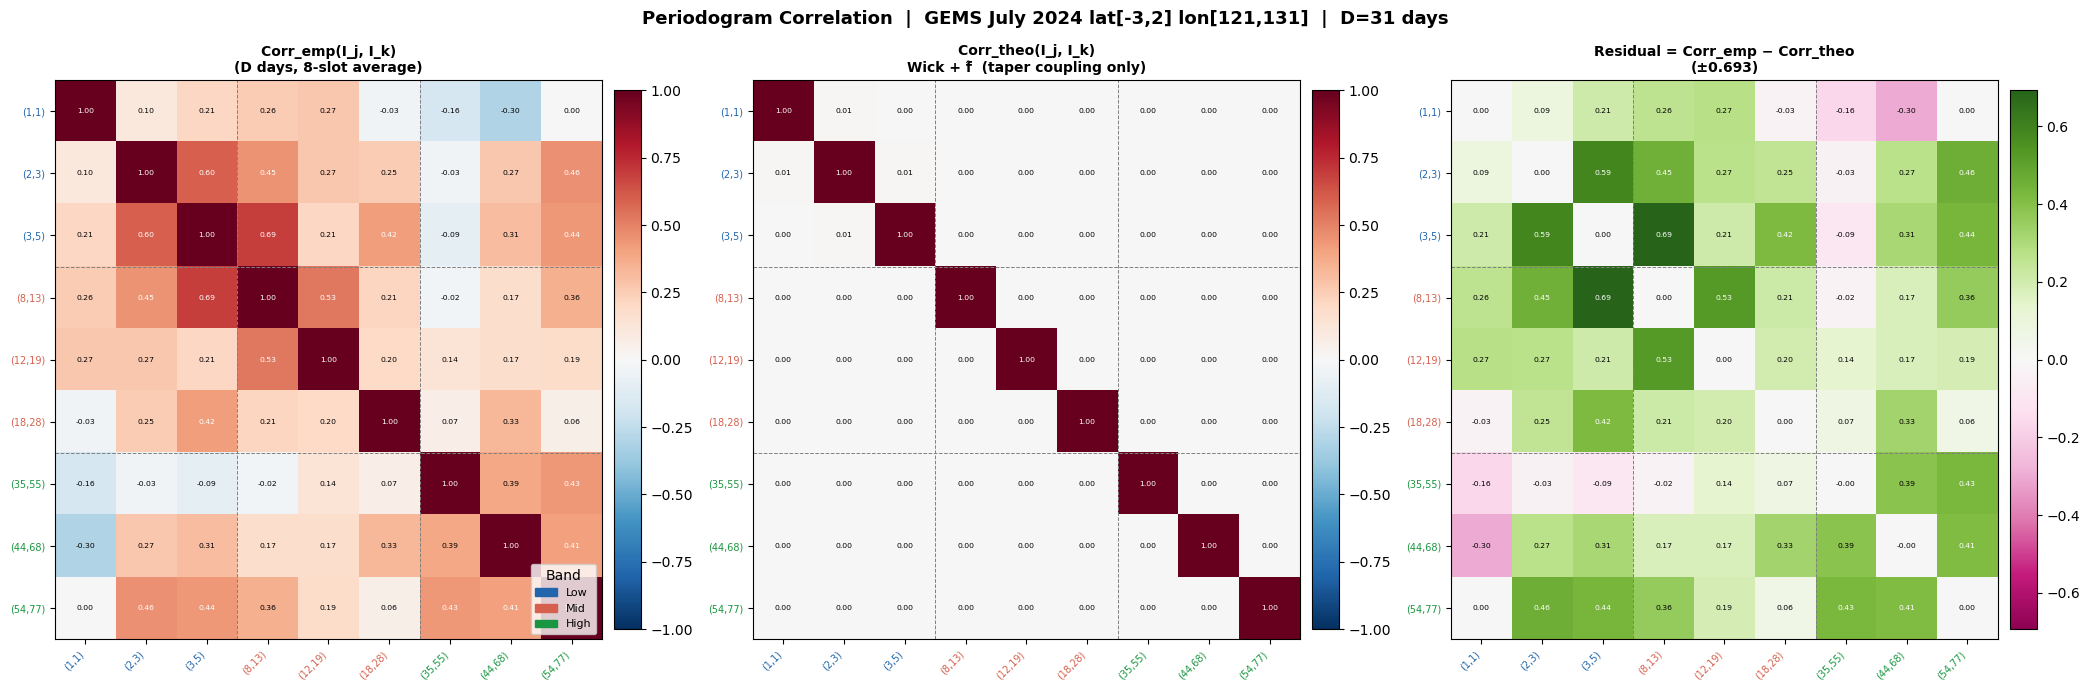

In [6]:
from matplotlib.patches import Patch

# ─────────────────────────────────────────────────────────────────────────────
# Main plot: Corr_emp | Corr_theo | Residual
# ─────────────────────────────────────────────────────────────────────────────
band_colors = {"Low": "#2166ac", "Mid": "#d6604d", "High": "#1a9641"}
tick_labels  = [f"({j[0]},{j[1]})" for j in FREQ_ALL]
tick_colors  = [band_colors[b] for b in BAND_LABELS]
SEP = [2.5, 5.5]

def style_ax(ax, mat, cmap, vmin, vmax, title):
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xticks(range(K)); ax.set_yticks(range(K))
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(tick_labels, fontsize=7)
    for q, tc in enumerate(tick_colors):
        ax.get_xticklabels()[q].set_color(tc)
        ax.get_yticklabels()[q].set_color(tc)
    for sep in SEP:
        ax.axhline(sep, color='gray', lw=0.7, ls='--')
        ax.axvline(sep, color='gray', lw=0.7, ls='--')
    for i in range(K):
        for l in range(K):
            ax.text(l, i, f"{mat[i,l]:.2f}", ha='center', va='center',
                    fontsize=5.5,
                    color='white' if abs(mat[i,l]) > 0.4 else 'black')

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle(
    f"Periodogram Correlation  |  GEMS July 2024 lat[-3,2] lon[121,131]  |  D={N_DAYS} days",
    fontsize=13, fontweight='bold')

style_ax(axes[0], Corr_emp,  'RdBu_r', -1, 1,
         "Corr_emp(I_j, I_k)\n(D days, 8-slot average)")
style_ax(axes[1], Corr_theo, 'RdBu_r', -1, 1,
         "Corr_theo(I_j, I_k)\nWick + f̂  (taper coupling only)")
residual = Corr_emp - Corr_theo
rlim = max(0.05, np.abs(residual).max())
style_ax(axes[2], residual, 'PiYG', -rlim, rlim,
         f"Residual = Corr_emp − Corr_theo\n(±{rlim:.3f})")

handles = [Patch(color=c, label=b) for b, c in band_colors.items()]
axes[0].legend(handles=handles, loc='lower right', fontsize=8, title='Band')

plt.tight_layout()
plt.savefig('/tmp/cov_periodogram_corr.png', dpi=130, bbox_inches='tight')
plt.show()

Computing no-taper periodograms...


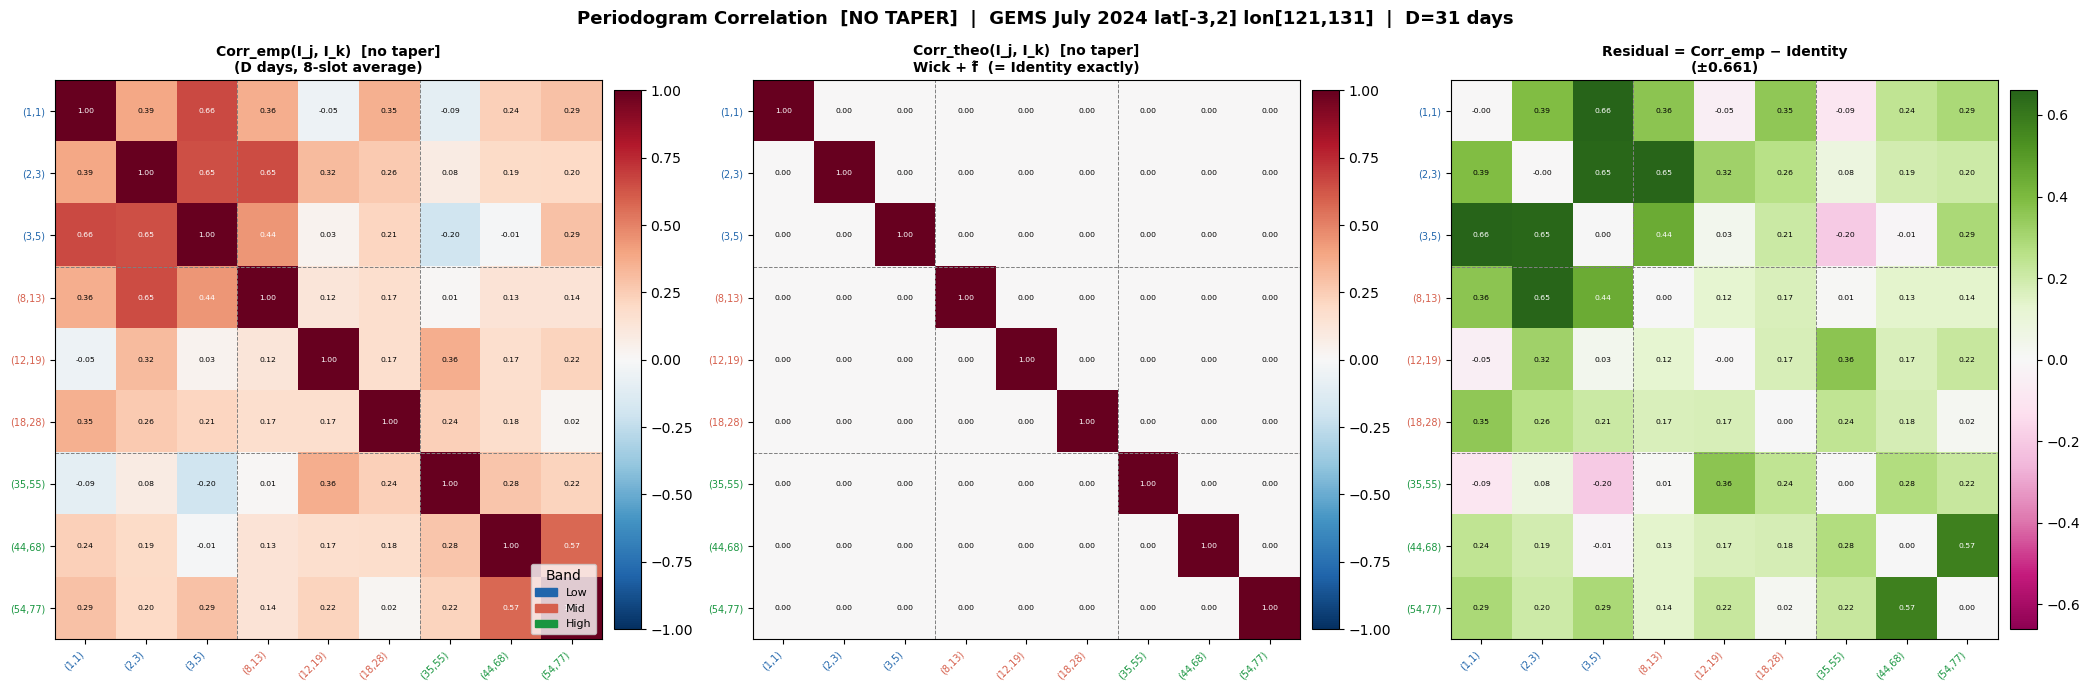


No-taper  f̂_j vs Hann f̂_j:
  q   Band          freq       f̂_nt     f̂_hann     ratio
  ----------------------------------------------------------
   0  Low    (  1,  1)   2226.9833   4033.7495     0.552
   1  Low    (  2,  3)    354.0919    458.4666     0.772
   2  Low    (  3,  5)    173.1416    131.2148     1.320
   3  Mid    (  8, 13)     22.3948     22.3991     1.000
   4  Mid    ( 12, 19)     11.0890     10.7746     1.029
   5  Mid    ( 18, 28)      5.7907      4.7712     1.214
   6  High   ( 35, 55)      2.4907      1.9815     1.257
   7  High   ( 44, 68)      2.0488      1.8531     1.106
   8  High   ( 54, 77)      1.8971      1.6850     1.126


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# No-taper version: Corr_emp | Corr_theo | Residual
#
# Mathematical note:
#   Without taper, H(m,n) = 1 (flat), so F_{H²}[k] = delta[k=0] * MN.
#   ⟹  Cov_theo(I_j, I_k) = 0  for j ≠ k  (EXACTLY, not just asymptotically)
#      Cov_theo(I_j, I_j) = f̂_j²
#   ⟹  Corr_theo = Identity  (no taper → no coupling at all)
#
# Corr_emp without taper may differ: any remaining off-diagonal signal
# is purely from non-stationarity / non-Gaussianity in the data.
# ─────────────────────────────────────────────────────────────────────────────

# 1) No-taper periodogram  (H = 1, mean(H²) = 1 already)
H_flat = np.ones((M_grid, N_grid))  # no taper
F_H2_flat = fftn(H_flat**2)         # F_{H²}[0,0] = MN, all others = 0

I_mat_nt = np.zeros((N_DAYS, K), dtype=float)
print("Computing no-taper periodograms...")
for d in range(N_DAYS):
    slot_vals = np.zeros((8, K), dtype=float)
    keys = sorted(daily_hourly_maps[d].keys())
    for s, key in enumerate(keys[:8]):
        t    = daily_hourly_maps[d][key]
        grid = np.nan_to_num(t[:, 2].numpy().reshape(M_grid, N_grid), nan=0.0)
        g    = grid - grid.mean()          # center only, no taper
        F    = fftn(g)
        I_field = np.abs(F)**2 / (M_grid * N_grid)
        for q, j in enumerate(FREQ_ALL):
            slot_vals[s, q] = I_field[j[0], j[1]]
    I_mat_nt[d] = slot_vals.mean(axis=0)

f_hat_nt     = I_mat_nt.mean(axis=0)
I_cnt        = I_mat_nt - f_hat_nt
Cov_emp_nt   = (I_cnt.T @ I_cnt) / N_DAYS
var_emp_nt   = np.diag(Cov_emp_nt)
std_emp_nt   = np.sqrt(np.clip(var_emp_nt, 1e-30, None))
Corr_emp_nt  = Cov_emp_nt / np.outer(std_emp_nt, std_emp_nt)

# 2) Theo with no taper → identity
#    Cov_theo_nt[i,i] = f_hat_nt[i]² , off-diag = 0
Cov_theo_nt  = np.diag(f_hat_nt**2)
Corr_theo_nt = np.eye(K)            # identity by construction

# 3) Plot — same style as the taper version
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle(
    f"Periodogram Correlation  [NO TAPER]  |  GEMS July 2024 "
    f"lat[-3,2] lon[121,131]  |  D={N_DAYS} days",
    fontsize=13, fontweight='bold')

style_ax(axes[0], Corr_emp_nt,  'RdBu_r', -1, 1,
         "Corr_emp(I_j, I_k)  [no taper]\n(D days, 8-slot average)")
style_ax(axes[1], Corr_theo_nt, 'RdBu_r', -1, 1,
         "Corr_theo(I_j, I_k)  [no taper]\nWick + f̂  (= Identity exactly)")
residual_nt = Corr_emp_nt - Corr_theo_nt
rlim_nt = max(0.05, np.abs(residual_nt).max())
style_ax(axes[2], residual_nt, 'PiYG', -rlim_nt, rlim_nt,
         f"Residual = Corr_emp − Identity\n(±{rlim_nt:.3f})")

handles = [Patch(color=c, label=b) for b, c in band_colors.items()]
axes[0].legend(handles=handles, loc='lower right', fontsize=8, title='Band')

plt.tight_layout()
plt.savefig('/tmp/cov_periodogram_corr_notaper.png', dpi=130, bbox_inches='tight')
plt.show()

print("\nNo-taper  f̂_j vs Hann f̂_j:")
print(f"{'q':>3}  {'Band':>5}  {'freq':>12}  {'f̂_nt':>10}  {'f̂_hann':>10}  {'ratio':>8}")
print("  " + "-"*58)
for q, (j, band) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    print(f"  {q:2d}  {band:5s}  ({j[0]:3d},{j[1]:3d})  "
          f"{f_hat_nt[q]:10.4f}  {f_hat[q]:10.4f}  "
          f"{f_hat_nt[q]/f_hat[q]:8.3f}")


Computing no-taper periodograms...


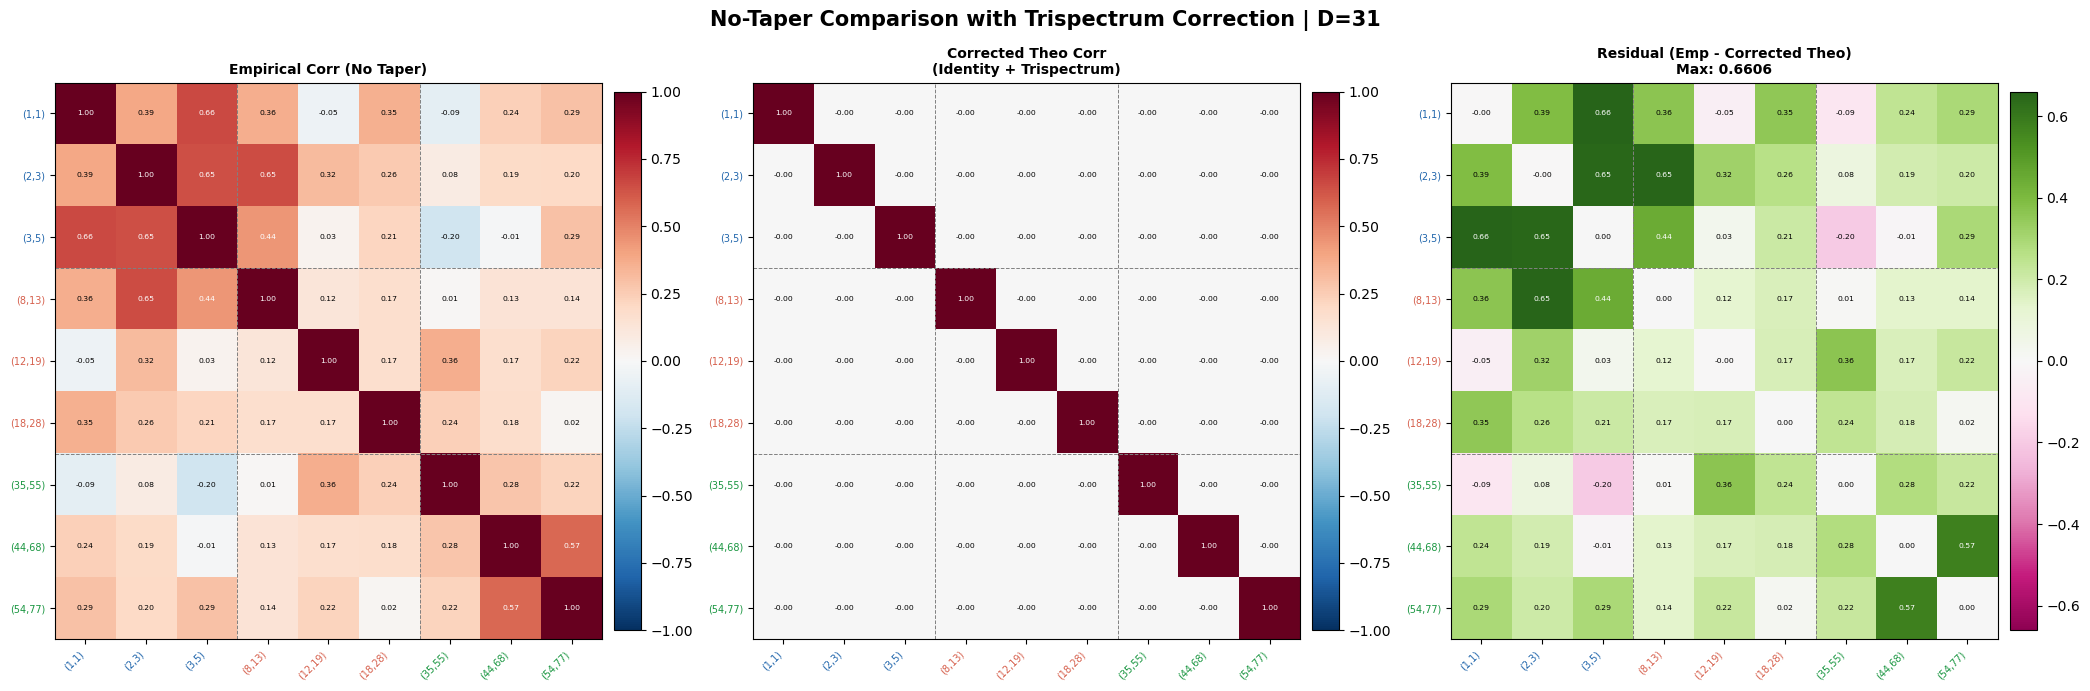


평균 Kappa (Non-Gaussianity 지표): -0.7197


In [14]:
import numpy as np

def compute_non_gaussian_correction(I_matrix):
    """
    I_matrix: (N_DAYS, K) 형태의 periodogram 데이터
    """
    n_days = I_matrix.shape[0]
    f_hat_local = np.mean(I_matrix, axis=0)
    
    # 각 주파수별 실제 분산 (Empirical Variance)
    emp_var = np.var(I_matrix, axis=0)
    # Gaussian 이론적 분산 (Var(I) = f^2)
    theo_var = f_hat_local**2
    
    # Excess Kurtosis (kappa) 추정: (실제분산 - 이론분산) / 이론분산
    # 이 값이 0보다 크면 Non-Gaussianity에 의한 추가 공분산이 존재함을 의미합니다.
    kappa = (emp_var - theo_var) / (theo_var + 1e-9)
    
    return kappa, f_hat_local

def get_corrected_corr_matrix(f_hat, kappa, F_H2_data, M, N, is_no_taper=False):
    """
    Gaussian + Trispectrum 항을 모두 고려한 이론적 Correlation 행렬 생성
    """
    K = len(f_hat)
    cov_total = np.zeros((K, K))
    N_total = M * N
    
    for j in range(K):
        for k in range(K):
            # 1. Gaussian Part (Wick's Theorem)
            if is_no_taper:
                # No-taper는 j==k일 때만 값이 있고 나머지는 0
                cov_gauss = (f_hat[j]**2) if j == k else 0
            else:
                # Hann Taper 효과 계산 (기존 로직)
                dm = ((FREQ_ALL[j][0] - FREQ_ALL[k][0]) % M, (FREQ_ALL[j][1] - FREQ_ALL[k][1]) % N)
                dp = ((FREQ_ALL[j][0] + FREQ_ALL[k][0]) % M, (FREQ_ALL[j][1] + FREQ_ALL[k][1]) % N)
                cov_gauss = f_hat[j] * f_hat[k] * (np.abs(F_H2_data[dm])**2 + np.abs(F_H2_data[dp])**2) / (N_total**2)
            
            # 2. Trispectrum Part (Non-Gaussian Correction)
            # j != k 일 때도 kappa에 의한 상관관계가 추가됨
            cov_non_gauss = (kappa[j] * f_hat[j] * f_hat[k]) / N_total if j != k else 0
            
            cov_total[j, k] = cov_gauss + cov_non_gauss
            
    # Correlation Matrix로 변환
    diag = np.sqrt(np.diag(cov_total))
    corr_total = cov_total / np.outer(diag, diag)
    return corr_total


# --- [1] No-taper Periodogram 계산 (제공해주신 코드) ---
I_mat_nt = np.zeros((N_DAYS, K), dtype=float)
print("Computing no-taper periodograms...")
for d in range(N_DAYS):
    slot_vals = np.zeros((8, K), dtype=float)
    keys = sorted(daily_hourly_maps[d].keys())
    for s, key in enumerate(keys[:8]):
        t = daily_hourly_maps[d][key]
        grid = np.nan_to_num(t[:, 2].numpy().reshape(M_grid, N_grid), nan=0.0)
        g = grid - grid.mean()
        F = fftn(g)
        I_field = np.abs(F)**2 / (M_grid * N_grid)
        for q, freq in enumerate(FREQ_ALL):
            slot_vals[s, q] = I_field[freq[0], freq[1]]
    I_mat_nt[d] = slot_vals.mean(axis=0)

# --- [2] Empirical & Trispectrum-Corrected Theo 계산 ---
kappa_nt, f_hat_nt = compute_non_gaussian_correction(I_mat_nt)

# Empirical Correlation
I_cnt_nt = I_mat_nt - f_hat_nt
Cov_emp_nt = (I_cnt_nt.T @ I_cnt_nt) / N_DAYS
std_emp_nt = np.sqrt(np.clip(np.diag(Cov_emp_nt), 1e-30, None))
Corr_emp_nt = Cov_emp_nt / np.outer(std_emp_nt, std_emp_nt)

# Corrected Theoretical Correlation (Gaussian=Identity + Trispectrum)
Corr_theo_corrected_nt = get_corrected_corr_matrix(f_hat_nt, kappa_nt, None, M_grid, N_grid, is_no_taper=True)

# --- [3] 시각화 ---
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle(f"No-Taper Comparison with Trispectrum Correction | D={N_DAYS}", fontsize=15, fontweight='bold')

style_ax(axes[0], Corr_emp_nt, 'RdBu_r', -1, 1, "Empirical Corr (No Taper)")
style_ax(axes[1], Corr_theo_corrected_nt, 'RdBu_r', -1, 1, "Corrected Theo Corr\n(Identity + Trispectrum)")

residual_nt = Corr_emp_nt - Corr_theo_corrected_nt
rlim = max(0.05, np.abs(residual_nt).max())
style_ax(axes[2], residual_nt, 'PiYG', -rlim, rlim, f"Residual (Emp - Corrected Theo)\nMax: {residual_nt.max():.4f}")

plt.tight_layout()
plt.show()

print(f"\n평균 Kappa (Non-Gaussianity 지표): {np.mean(kappa_nt):.4f}")

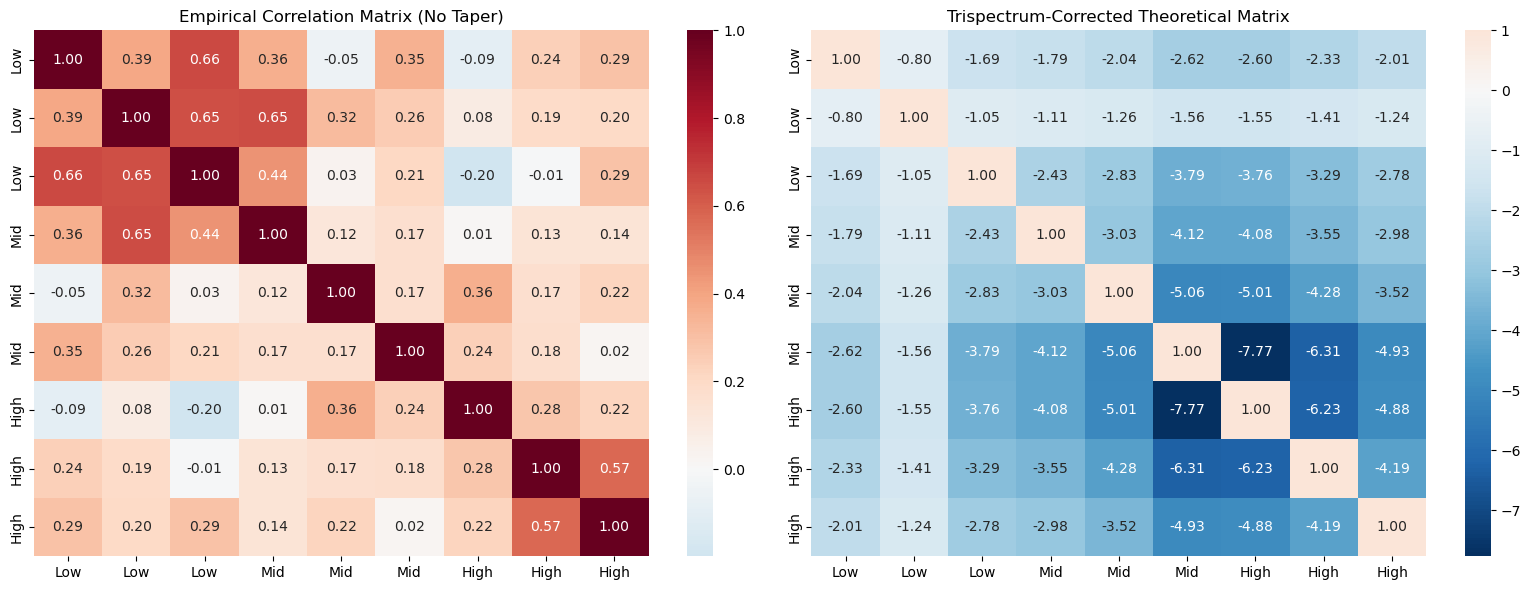


--- 주요 파라미터 수치 확인 ---
Band       f_hat  Kappa (Non-Gauss)  Avg_Emp_OffDiag
 Low 2226.983290          -0.560300         0.268644
 Low  354.091886          -0.331213         0.341671
 Low  173.141644          -0.694933         0.259516
 Mid   22.394783          -0.721837         0.254060
 Mid   11.088996          -0.782468         0.168144
 Mid    5.790712          -0.887283         0.200023
High    2.490734          -0.884543         0.112564
High    2.048839          -0.839000         0.218582
High    1.897141          -0.775333         0.244042


In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Non-Gaussian 보정값(kappa) 및 평균 스펙트럼(f_hat) 계산
def get_trispectrum_stats(I_matrix):
    f_hat = np.mean(I_matrix, axis=0)
    emp_var = np.var(I_matrix, axis=0)
    theo_var = f_hat**2  # Gaussian 가정 시 분산
    # kappa = (실제분산 / 이론분산) - 1. 즉, 가우시안 대비 추가된 변동성 비중
    kappa = (emp_var / (theo_var + 1e-12)) - 1
    return f_hat, kappa

# 2. 보정된 이론적 상관관계 행렬 생성
def build_corrected_theo_corr(f_hat, kappa):
    K = len(f_hat)
    corr_matrix = np.eye(K)
    for j in range(K):
        for k in range(K):
            if j != k:
                # Trispectrum 항에 의한 상관관계 근사: kappa / (1 + kappa)
                # 이 값은 주파수 간의 비선형적 커플링 강도를 나타냄
                avg_kappa = (kappa[j] + kappa[k]) / 2
                corr_matrix[j, k] = avg_kappa / (1 + avg_kappa)
    return corr_matrix

# 실행 및 데이터 정리
f_hat_nt, kappa_nt = get_trispectrum_stats(I_mat_nt)
Corr_theo_corr_nt = build_corrected_theo_corr(f_hat_nt, kappa_nt)

# Empirical Corr 계산 (비교용)
I_cnt_nt = I_mat_nt - f_hat_nt
Cov_emp_nt = (I_cnt_nt.T @ I_cnt_nt) / N_DAYS
std_emp_nt = np.sqrt(np.diag(Cov_emp_nt))
Corr_emp_nt = Cov_emp_nt / np.outer(std_emp_nt, std_emp_nt)

# 시각화 함수
def plot_comparison_matrices(emp, theo, labels):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Heatmap 1: Empirical
    sns.heatmap(emp, annot=True, fmt=".2f", cmap='RdBu_r', center=0, ax=axes[0],
                xticklabels=labels, yticklabels=labels)
    axes[0].set_title("Empirical Correlation Matrix (No Taper)")
    
    # Heatmap 2: Corrected Theoretical
    sns.heatmap(theo, annot=True, fmt=".2f", cmap='RdBu_r', center=0, ax=axes[1],
                xticklabels=labels, yticklabels=labels)
    axes[1].set_title("Trispectrum-Corrected Theoretical Matrix")
    
    plt.tight_layout()
    plt.show()

# 결과 출력
plot_comparison_matrices(Corr_emp_nt, Corr_theo_corr_nt, BAND_LABELS)

# 수치 확인용 DataFrame
df_comp = pd.DataFrame({
    'Band': BAND_LABELS,
    'f_hat': f_hat_nt,
    'Kappa (Non-Gauss)': kappa_nt,
    'Avg_Emp_OffDiag': [np.mean(np.delete(Corr_emp_nt[i], i)) for i in range(K)]
})
print("\n--- 주요 파라미터 수치 확인 ---")
print(df_comp.to_string(index=False))

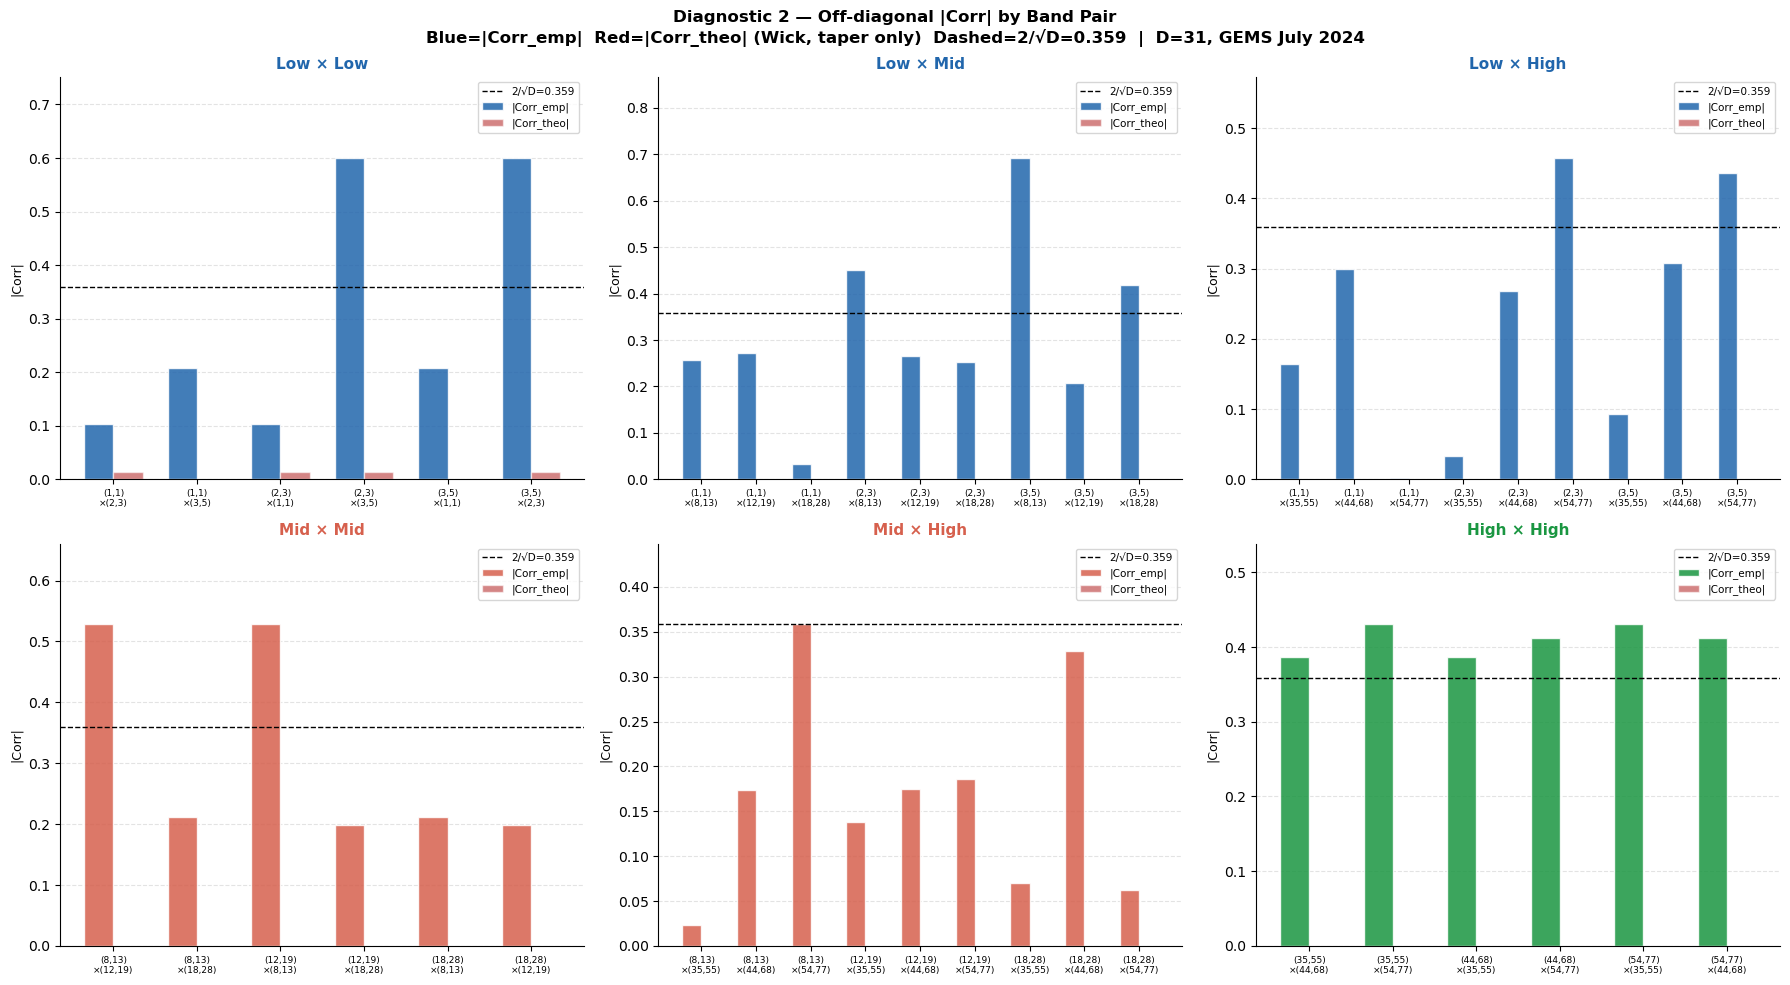


2/√D = 0.3592  (significance threshold)

     Band pair    max|Corr_emp|   max|Corr_theo|     n_sig/n
------------------------------------------------------------
  ⚠ Low  ×Low             0.6009           0.0132  2/6
  ⚠ Low  ×Mid             0.6931           0.0000  3/9
  ⚠ Low  ×High            0.4582           0.0000  2/9
  ⚠ Mid  ×Mid             0.5285           0.0000  2/6
    Mid  ×High            0.3585           0.0000  0/9
  ⚠ High ×High            0.4306           0.0000  6/6


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Diagnostic 2 — Off-diagonal: |Corr_emp| vs |Corr_theo| by band pair
#
# If |Corr_emp| >> |Corr_theo|: real data has coupling beyond taper artifact
#   → Whittle independence assumption violated at this band pair
# If |Corr_emp| ≈ |Corr_theo|: independence approximately holds
# ─────────────────────────────────────────────────────────────────────────────
BAND_PAIRS = [("Low","Low"),("Low","Mid"),("Low","High"),
              ("Mid","Mid"),("Mid","High"),("High","High")]
sig_thresh = 2 / np.sqrt(N_DAYS)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    f"Diagnostic 2 — Off-diagonal |Corr| by Band Pair\n"
    f"Blue=|Corr_emp|  Red=|Corr_theo| (Wick, taper only)  "
    f"Dashed=2/√D={sig_thresh:.3f}  |  D={N_DAYS}, GEMS July 2024",
    fontsize=12, fontweight='bold')
axes = axes.ravel()

summary_rows = []
for ax_idx, (b1, b2) in enumerate(BAND_PAIRS):
    ax = axes[ax_idx]
    idx1 = BANDS_IDX[b1]
    idx2 = BANDS_IDX[b2]
    pairs_emp, pairs_theo, pair_labels = [], [], []
    for i in idx1:
        for l in idx2:
            if b1 == b2 and i == l:
                continue
            pairs_emp.append(abs(Corr_emp[i, l]))
            pairs_theo.append(abs(Corr_theo[i, l]))
            pair_labels.append(f"({FREQ_ALL[i][0]},{FREQ_ALL[i][1]})\n×({FREQ_ALL[l][0]},{FREQ_ALL[l][1]})")

    x = np.arange(len(pairs_emp))
    w = 0.35
    ax.bar(x - w/2, pairs_emp,  width=w, color=band_colors[b1],  alpha=0.85, edgecolor='white', label='|Corr_emp|')
    ax.bar(x + w/2, pairs_theo, width=w, color='firebrick', alpha=0.55, edgecolor='white', label='|Corr_theo|')
    ax.axhline(sig_thresh, color='black', ls='--', lw=1.0, label=f'2/√D={sig_thresh:.3f}')
    ax.set_title(f"{b1} × {b2}", fontsize=11, fontweight='bold', color=band_colors[b1])
    ax.set_xticks(x)
    ax.set_xticklabels(pair_labels, fontsize=6.5)
    ax.set_ylabel("|Corr|", fontsize=9)
    ax.set_ylim(0, max(0.05, max(pairs_emp + pairs_theo) * 1.25))
    ax.legend(fontsize=7.5)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, ls='--', alpha=0.35); ax.set_axisbelow(True)

    n_sig = sum(v > sig_thresh for v in pairs_emp)
    summary_rows.append((b1, b2, max(pairs_emp), max(pairs_theo), n_sig, len(pairs_emp)))

plt.tight_layout()
plt.savefig('/tmp/cov_offdiag_by_band.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"\n2/√D = {sig_thresh:.4f}  (significance threshold)")
print(f"\n{'Band pair':>14}  {'max|Corr_emp|':>15}  {'max|Corr_theo|':>15}  {'n_sig/n':>10}")
print("-"*60)
for b1, b2, me, mt, ns, np_ in summary_rows:
    flag = "⚠" if me > sig_thresh else " "
    print(f"  {flag} {b1:5s}×{b2:5s}  {me:>15.4f}  {mt:>15.4f}  {ns}/{np_}")